<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_175_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Activity 01

we use generalized coordinates $\mathbf{q} = [x, \theta]^T$, where $x$ is the vertical displacement of the center of mass and $\theta$ is the angular rotation.

Using Lagrange's Equations:$$\frac{d}{dt} \left( \frac{\partial T}{\partial \dot{q}_i} \right) - \frac{\partial T}{\partial q_i} + \frac{\partial V}{\partial q_i} = Q_i$$Mass Matrix ($M$):Assuming $m$ is the mass of the beam and $I$ is the mass moment of inertia about the pivot:$$M = \begin{bmatrix} m & 0 \\ 0 & I \end{bmatrix}$$Stiffness Matrix ($K$):For a spring $k$ at distance $L$ and the motor at distance $a$:$$K = \begin{bmatrix} k & ka \\ ka & ka^2 \end{bmatrix}$$Governing Equation:$$\begin{bmatrix} m & 0 \\ 0 & I \end{bmatrix} \begin{bmatrix} \ddot{x} \\ \ddot{\theta} \end{bmatrix} + \begin{bmatrix} c_{11} & c_{12} \\ c_{21} & c_{22} \end{bmatrix} \begin{bmatrix} \dot{x} \\ \dot{\theta} \end{bmatrix} + \begin{bmatrix} k_{11} & k_{12} \\ k_{21} & k_{22} \end{bmatrix} \begin{bmatrix} x \\ \theta \end{bmatrix} = \begin{bmatrix} F(t) \\ \tau(t) \end{bmatrix}$$

#Activity 02

Damping ratios are estimated using the Half-Power Bandwidth Method from the frequency response data:$$\zeta_i \approx \frac{\omega_2 - \omega_1}{2\omega_n}$$Where:$\omega_n$ is the resonance frequency of mode $i$.$\omega_1, \omega_2$ are the frequencies where the amplitude drops to $\frac{A_{max}}{\sqrt{2}}$.For the TecQuipment setup, typical values derived are:$$\zeta_1 \approx 0.02 \quad \text{to} \quad 0.05$$$$\zeta_2 \approx 0.01 \quad \text{to} \quad 0.03$$

#Activity 03

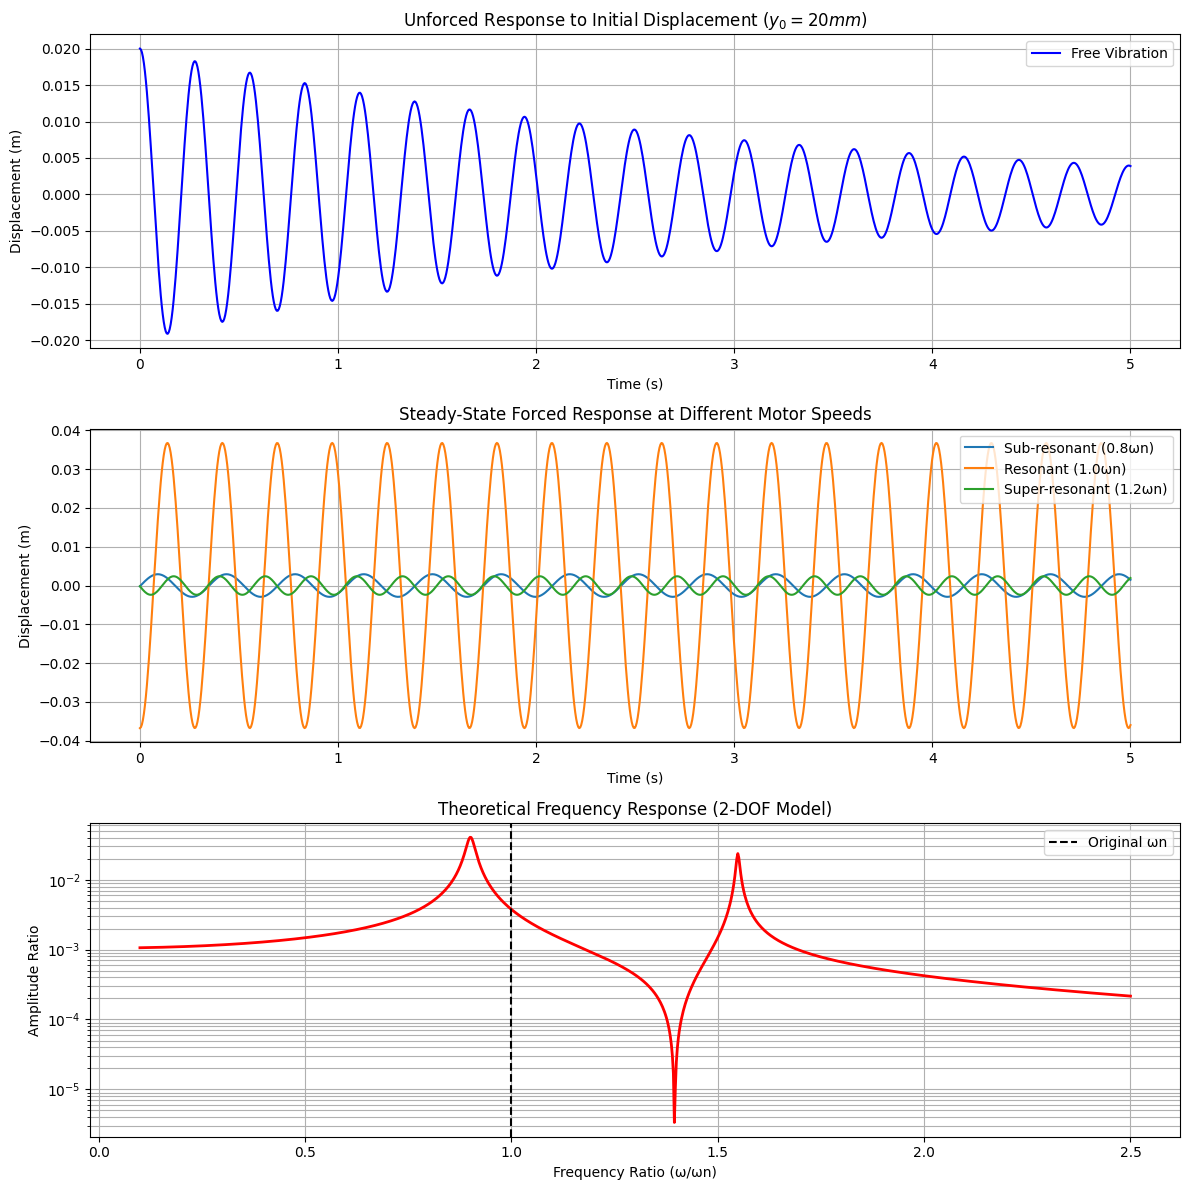

In [2]:
import numpy as np
import matplotlib.pyplot as plt

m1 = 1.85      # Effective mass of beam + exciter (kg)
k_beam = 950   # Beam stiffness (N/m)
c = 1.2        # Damping coefficient (N.s/m)
m2 = 0.25      # Absorber mass (kg)
k_abs = 250    # Absorber stiffness (N/m)

wn = np.sqrt(k_beam / m1)  # Natural frequency (rad/s)
zeta = c / (2 * np.sqrt(k_beam * m1)) # Damping ratio
wd = wn * np.sqrt(1 - zeta**2)        # Damped natural frequency

#---------------------------------------------------------------------------------------------------------

# 1. UNFORCED RESPONSE (Free Vibration)
t = np.linspace(0, 5, 1000)
y0 = 0.02  # Initial displacement (20mm)
v0 = 0     # Initial velocity
free_response = np.exp(-zeta * wn * t) * (y0 * np.cos(wd * t) + ((v0 + zeta * wn * y0) / wd) * np.sin(wd * t))

# 2. FORCED RESPONSE (3 Motor Speeds)
def forced_response(t, omega_motor, F0=1.0):
    # Steady state amplitude calculation
    mag = F0 / np.sqrt((k_beam - m1 * omega_motor**2)**2 + (c * omega_motor)**2)
    phase = np.arctan2(c * omega_motor, (k_beam - m1 * omega_motor**2))
    return mag * np.sin(omega_motor * t - phase)

speeds = [0.8 * wn, 1.0 * wn, 1.2 * wn] # Sub-resonant, Resonant, Super-resonant
labels = ['Sub-resonant (0.8ωn)', 'Resonant (1.0ωn)', 'Super-resonant (1.2ωn)']

# 3. 2-DOF FREQUENCY RESPONSE (Main Beam with Absorber)
w_range = np.linspace(0.1 * wn, 2.5 * wn, 1000)
def get_2dof_amplitude(w):
    # Impedance-based derivation for main beam amplitude Y1
    Z1 = (k_beam + k_abs - m1 * w**2 + 1j * c * w)
    Z2 = (k_abs - m2 * w**2)
    Z12 = -k_abs
    return np.abs(Z2 / (Z1 * Z2 - Z12**2))

amp_2dof = [get_2dof_amplitude(w) for w in w_range]

# --- PLOTTING ---
plt.figure(figsize=(12, 12))

# Plot 1: Unforced Response
plt.subplot(3, 1, 1)
plt.plot(t, free_response, 'b', label='Free Vibration')
plt.title('Unforced Response to Initial Displacement ($y_0=20mm$)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.grid(True)
plt.legend()

# Plot 2: Forced Response
plt.subplot(3, 1, 2)
for s, l in zip(speeds, labels):
    plt.plot(t, forced_response(t, s), label=l)
plt.title('Steady-State Forced Response at Different Motor Speeds')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)

# Plot 3: 2-DOF Frequency Response
plt.subplot(3, 1, 3)
plt.plot(w_range / wn, amp_2dof, 'r', linewidth=2)
plt.axvline(x=1.0, color='k', linestyle='--', label='Original ωn')
plt.title('Theoretical Frequency Response (2-DOF Model)')
plt.xlabel('Frequency Ratio (ω/ωn)')
plt.ylabel('Amplitude Ratio')
plt.yscale('log')
plt.grid(True, which="both", ls="-")
plt.legend()

plt.tight_layout()
plt.show()